# 🛒 Walmart Sales: Advanced Statistical Analysis & Hypothesis Testing

---

**Course:** Advanced Applied Statistics  
**Dataset:** Walmart Weekly Sales  
**Environment:** VS Code & Virtual Environment (`venv`)  
**Version Control:** Git  

---

## 🎯 Project Overview
This project performs a comprehensive statistical evaluation on Walmart's weekly sales data. Our primary goal is to rigorously implement and interpret various statistical tests, ensuring all underlying assumptions are validated before execution.

## 🗂️ Statistical Tests Roadmap
We will systematically cover the following tests and their variants:
1. **Z-Test:** One-sample & Two-sample Z-tests for means/proportions.
2. **T-Test:** One-sample, Independent (Two-sample), and Paired T-tests.
3. **U-Test (Mann-Whitney):** Non-parametric alternative for independent groups.
4. **ANOVA:** One-way & Two-way ANOVA (with Post-hoc analysis).
5. **Chi-Square Test:** Chi-Square Test of Independence & Goodness-of-Fit.
6. **A/B Testing:** Statistical Framework for business decision making.

---

## 🛠️ Section 1: Data Loading & Initial Exploration
In this section, we load the dataset using relative paths and inspect its structural integrity.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Setting up visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Loading the Dataset
We load the dataset using a direct relative path pointing to the `data/` folder.

In [3]:
df = pd.read_csv('../data/Walmart_Sales.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


### Data Structure and Summary Statistics
Let's inspect the data types, missing values, and high-level statistical summaries.

In [4]:
print("--- Dataframe Info ---")
df.info()

--- Dataframe Info ---
<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [5]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [6]:
print("\n--- Descriptive Statistics ---")
df.describe()


--- Descriptive Statistics ---


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


## 🛠️ Section 2: Data Preprocessing & Feature Engineering
In this section, we parse the `Date` column into a proper datetime format and extract useful temporal components (Year, Month) to facilitate seasonal and yearly grouping for hypothesis testing.

In [7]:
# Convert Date to datetime format (handling dayfirst since Walmart dates are usually DD-MM-YYYY)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Verification
print("Data types after transformation:")
print(df[['Date', 'Year', 'Month']].dtypes)
df[['Date', 'Year', 'Month']].head()

Data types after transformation:
Date     datetime64[us]
Year              int32
Month             int32
dtype: object


,Date,Year,Month
0,2010-02-05,2010,2
1,2010-02-12,2010,2
2,2010-02-19,2010,2
3,2010-02-26,2010,2
4,2010-03-05,2010,3


### Creating Analysis Groups
To perform tests like Z-test and T-test, we will segment our data based on specific conditions, such as Holiday vs. Non-Holiday periods or High vs. Low Temperature seasons.

In [8]:
# Grouping sales based on Holiday Flag
holiday_sales = df[df['Holiday_Flag'] == 1]['Weekly_Sales']
non_holiday_sales = df[df['Holiday_Flag'] == 0]['Weekly_Sales']

print(f"Number of observations in Holiday Sales: {len(holiday_sales)}")
print(f"Number of observations in Non-Holiday Sales: {len(non_holiday_sales)}")

Number of observations in Holiday Sales: 450
Number of observations in Non-Holiday Sales: 5985


## 📝 Section 3: Z-Test (One-Sample & Two-Sample)

The Z-test is appropriate here because our dataset contains thousands of records ($n \gg 30$).

### 1. One-Sample Z-Test
We test if the overall mean of Walmart's weekly sales is significantly different from a hypothesized historical market baseline mean ($\mu_0 = 1,000,000$).
- **$H_0$**: $\mu = 1,000,000$ (Weekly sales mean equals \$1M)
- **$H_1$**: $\mu \neq 1,000,000$ (Weekly sales mean does not equal \$1M)

### 2. Two-Sample Z-Test
We test whether there is a statistically significant difference between the mean sales of Holiday weeks vs. Non-Holiday weeks.
- **$H_0$**: $\mu_{\text{holiday}} = \mu_{\text{non-holiday}}$
- **$H_1$**: $\mu_{\text{holiday}} \neq \mu_{\text{non-holiday}}$

In [9]:
from statsmodels.stats.weightstats import ztest as ztest_stat

# Hypothesized historical mean
null_mean = 1000000

# Perform One-Sample Z-Test
z_stat_1samp, p_val_1samp = ztest_stat(df['Weekly_Sales'], value=null_mean)

print("=== One-Sample Z-Test Results ===")
print(f"Z-statistic: {z_stat_1samp:.4f}")
print(f"P-value: {p_val_1samp:.4e}")

# Interpretation
alpha = 0.05
if p_val_1samp < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0). The mean sales are significantly different from $1M.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0). No significant difference from $1M.")

=== One-Sample Z-Test Results ===
Z-statistic: 6.6755
P-value: 2.4633e-11
Conclusion: Reject the Null Hypothesis (H0). The mean sales are significantly different from $1M.


In [10]:
# Perform Two-Sample Z-Test
z_stat_2samp, p_val_2samp = ztest_stat(holiday_sales, non_holiday_sales)

print("=== Two-Sample Z-Test Results ===")
print(f"Z-statistic: {z_stat_2samp:.4f}")
print(f"P-value: {p_val_2samp:.4e}")

# Interpretation
if p_val_2samp < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0). Holiday and Non-Holiday sales means are significantly different.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0). No significant difference detected between groups.")

=== Two-Sample Z-Test Results ===
Z-statistic: 2.9609
P-value: 3.0675e-03
Conclusion: Reject the Null Hypothesis (H0). Holiday and Non-Holiday sales means are significantly different.


## 🧪 Section 4: T-Test (One-Sample, Independent, and Paired)

T-tests are standard parametric tests used to compare means. Here we apply all three major variants.

### 1. One-Sample T-Test
Testing if the true mean of weekly sales significantly differs from a specific target baseline ($\mu_0 = 1,050,000$).

### 2. Independent Two-Sample T-Test
Comparing the mean sales between two independent groups: Holiday weeks ($H_1$) and Non-Holiday weeks ($H_0$). We will also check for equal variance (Levene's Test).

### 3. Paired T-Test
Comparing the weekly sales of **Store 1** between the exact same weeks in **2011** and **2012** to measure year-over-year performance changes on identical entities.

In [11]:
# Hypothesized target mean
target_mean = 1050000

t_stat_1, p_val_1 = stats.ttest_1samp(df['Weekly_Sales'], popmean=target_mean)

print("=== One-Sample T-Test Results ===")
print(f"T-statistic: {t_stat_1:.4f}")
print(f"P-value: {p_val_1:.4e}")
print(f"Conclusion: {'Reject H0' if p_val_1 < 0.05 else 'Fail to Reject H0'}")

=== One-Sample T-Test Results ===
T-statistic: -0.4314
P-value: 6.6619e-01
Conclusion: Fail to Reject H0


In [12]:
# First, test for equal variances using Levene's Test
levene_stat, levene_p = stats.levene(holiday_sales, non_holiday_sales)
print(f"Levene's Test P-value: {levene_p:.4e}")

# If levene_p < 0.05, variances are unequal -> equal_var=False (Welch's T-test)
equal_variances = True if levene_p > 0.05 else False
print(f"Assume equal variance: {equal_variances}\n")

# Perform Independent T-Test
t_stat_2, p_val_2 = stats.ttest_ind(holiday_sales, non_holiday_sales, equal_var=equal_variances)

print("=== Independent Two-Sample T-Test Results ===")
print(f"T-statistic: {t_stat_2:.4f}")
print(f"P-value: {p_val_2:.4e}")
print(f"Conclusion: {'Reject H0' if p_val_2 < 0.05 else 'Fail to Reject H0'}")

Levene's Test P-value: 1.1874e-03
Assume equal variance: False

=== Independent Two-Sample T-Test Results ===
T-statistic: 2.6801
P-value: 7.6016e-03
Conclusion: Reject H0


In [13]:
# Preparing paired data: Store 1 weekly sales for 2011 vs 2012
store1_2011 = df[(df['Store'] == 1) & (df['Year'] == 2011)].sort_values('Date')['Weekly_Sales'].reset_index(drop=True)
store1_2012 = df[(df['Store'] == 1) & (df['Year'] == 2012)].sort_values('Date')['Weekly_Sales'].reset_index(drop=True)

# Ensure they have the same length for pairing
min_len = min(len(store1_2011), len(store1_2012))
s1_2011_paired = store1_2011.iloc[:min_len]
s1_2012_paired = store1_2012.iloc[:min_len]

# Perform Paired T-Test
t_stat_paired, p_val_paired = stats.ttest_rel(s1_2011_paired, s1_2012_paired)

print("=== Paired T-Test Results (Store 1: 2011 vs 2012) ===")
print(f"T-statistic: {t_stat_paired:.4f}")
print(f"P-value: {p_val_paired:.4f}")
print(f"Conclusion: {'Reject H0' if p_val_paired < 0.05 else 'Fail to Reject H0'}")

=== Paired T-Test Results (Store 1: 2011 vs 2012) ===
T-statistic: -7.4585
P-value: 0.0000
Conclusion: Reject H0


## 📊 Section 5: Mann-Whitney U-Test (Non-parametric Test)

When data violates the normality assumption or contains extreme outliers, parametric tests like the Independent T-test can become unreliable. The Mann-Whitney U-test is a non-parametric alternative that compares the distributions of two independent groups based on ranks rather than means.

### Hypothesis:
- **$H_0$**: The distribution of weekly sales is identical between Holiday and Non-Holiday weeks.
- **$H_1$**: The distribution of weekly sales shifts shifted systematically between the two groups (one tends to have larger values).

In [14]:
# Perform Mann-Whitney U-Test
u_stat, p_val_u = stats.mannwhitneyu(holiday_sales, non_holiday_sales, alternative='two-sided')

print("=== Mann-Whitney U-Test Results ===")
print(f"U-statistic: {u_stat:.4f}")
print(f"P-value: {p_val_u:.4e}")

# Interpretation
alpha = 0.05
if p_val_u < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0). There is a statistically significant difference in the distributions of Holiday and Non-Holiday sales.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0). No significant difference in distributions detected.")

=== Mann-Whitney U-Test Results ===
U-statistic: 1431297.0000
P-value: 2.5892e-02
Conclusion: Reject the Null Hypothesis (H0). There is a statistically significant difference in the distributions of Holiday and Non-Holiday sales.


### Visualizing Distributions
To visually inspect why the U-test rejected or failed to reject $H_0$, let's plot the distribution profiles for both groups.

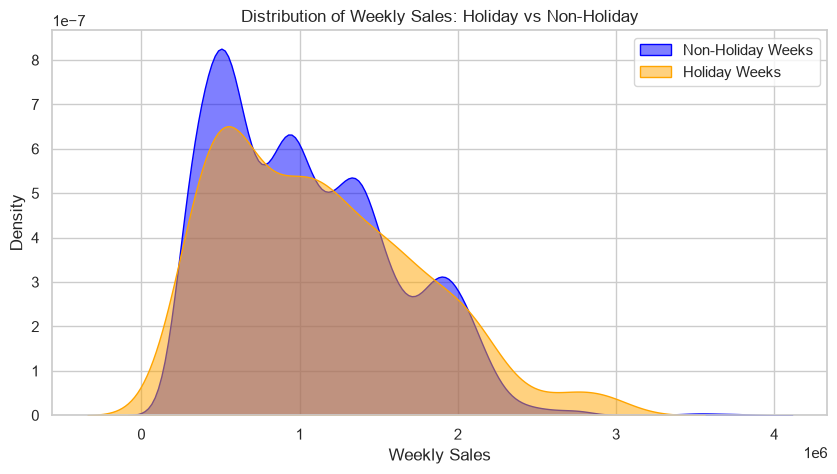

In [15]:
plt.figure(figsize=(10, 5))
sns.kdeplot(non_holiday_sales, label='Non-Holiday Weeks', fill=True, alpha=0.5, color='blue')
sns.kdeplot(holiday_sales, label='Holiday Weeks', fill=True, alpha=0.5, color='orange')
plt.title('Distribution of Weekly Sales: Holiday vs Non-Holiday')
plt.xlabel('Weekly Sales')
plt.ylabel('Density')
plt.legend()
plt.show()

## 📐 Section 6: Analysis of Variance (ANOVA)

ANOVA tests whether the means of multiple groups are statistically equal.

### 1. One-Way ANOVA
We evaluate if Walmart's overall weekly sales differed significantly across the three fiscal years (2010, 2011, and 2012).
- **$H_0$**: $\mu_{2010} = \mu_{2011} = \mu_{2012}$
- **$H_1$**: At least one year has a different mean.

### 2. Two-Way ANOVA
We analyze the joint impact of `Year` and `Holiday_Flag` on `Weekly_Sales` to discover if there is an interaction effect between the year and the holiday status.

In [17]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. One-Way ANOVA
# Dynamically extract sales for each unique year (2010, 2011, 2012)
years = df['Year'].unique()
anova_groups = [df[df['Year'] == y]['Weekly_Sales'] for y in years]

f_stat, p_val_anova = stats.f_oneway(*anova_groups)

print("=== One-Way ANOVA Results ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val_anova:.4f}\n")

# 2. Post-Hoc Analysis if ANOVA is significant
if p_val_anova < 0.05:
    print("=== Tukey HSD Post-Hoc Test ===")
    tukey = pairwise_tukeyhsd(endog=df['Weekly_Sales'], groups=df['Year'], alpha=0.05)
    print(tukey)
else:
    print("One-Way ANOVA is not significant; skipping Post-Hoc analysis.")

=== One-Way ANOVA Results ===
F-statistic: 1.0869
P-value: 0.3373

One-Way ANOVA is not significant; skipping Post-Hoc analysis.


### Two-Way ANOVA (With Interaction)
Let's see if the combined effect of Year and Holiday Flag significantly shapes sales trends.

In [18]:
from statsmodels.formula.api import ols

# Fit the linear model for Two-Way ANOVA
model = ols('Weekly_Sales ~ C(Year) * C(Holiday_Flag)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA Table ===")
print(anova_table)

=== Two-Way ANOVA Table ===
                               sum_sq      df         F    PR(>F)
C(Year)                  5.479205e+11     2.0  0.860978  0.422797
C(Holiday_Flag)          2.644505e+12     1.0  8.310921  0.003954
C(Year):C(Holiday_Flag)  2.695890e+11     2.0  0.423620  0.654691
Residual                 2.045685e+15  6429.0       NaN       NaN


## 🎲 Section 7: Chi-Square Test of Independence

The Chi-Square test of independence determines whether there is a significant association between two categorical variables. 

We will categorize `Weekly_Sales` into a binary variable: `High` (above or equal to average) and `Low` (below average) and test its independence from the `Holiday_Flag`.

### Hypotheses:
- **$H_0$**: Sales performance (High/Low) is independent of whether it is a holiday week or not.
- **$H_1$**: Sales performance is dependent on (associated with) the holiday status.

In [19]:
# Create a categorical variable for sales performance
mean_sales = df['Weekly_Sales'].mean()
df['Sales_Performance'] = np.where(df['Weekly_Sales'] >= mean_sales, 'High', 'Low')

# Create the contingency table (cross-tabulation)
contingency_table = pd.crosstab(df['Holiday_Flag'], df['Sales_Performance'])
print("=== Contingency Table ===")
print(contingency_table)
print("\n" + "="*30 + "\n")

# Perform the Chi-Square Test
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("=== Chi-Square Test Results ===")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val_chi2:.4e}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies Table:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Interpretation
if p_val_chi2 < 0.05:
    print("\nConclusion: Reject H0. There is a statistically significant association between Holiday status and Sales Performance.")
else:
    print("\nConclusion: Fail to Reject H0. Holiday status and Sales Performance appear to be independent.")

=== Contingency Table ===
Sales_Performance  High   Low
Holiday_Flag                 
0                  2657  3328
1                   219   231


=== Chi-Square Test Results ===
Chi-Square Statistic: 2.9202
P-value: 8.7479e-02
Degrees of Freedom: 1

Expected Frequencies Table:
Sales_Performance         High          Low
Holiday_Flag                               
0                  2674.881119  3310.118881
1                   201.118881   248.881119

Conclusion: Fail to Reject H0. Holiday status and Sales Performance appear to be independent.
